# Unitary Synthesiser 101
Description of how to run the synthesiser and what functions are available and what they do.

First, we start by importing the necessary modules

In [25]:
from Unitary_Synthesis_V2 import UnitarySynthesiser
from decomposition_nodes import SingleQubitNode, AIIINode, TypeANode, IdentityNode
import numpy as np

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)


To construct our synthesiser, we need to create a unitary.

In [26]:
unitary = 1/np.sqrt(2)* np.array(
    [
        [1, 1j, 0, 0], 
        [0, 0, 1j, 1],
        [0, 0, 1j, -1],
        [1, -1j, 0, 0]
     ]
    )  # "Magic gate"


print(unitary)

[[ 0.70710678+0.j          0.        +0.70710678j  0.        +0.j
   0.        +0.j        ]
 [ 0.        +0.j          0.        +0.j          0.        +0.70710678j
   0.70710678+0.j        ]
 [ 0.        +0.j          0.        +0.j          0.        +0.70710678j
  -0.70710678+0.j        ]
 [ 0.70710678+0.j          0.        -0.70710678j  0.        +0.j
   0.        +0.j        ]]


We can then construct the synthesiser like this: 
(Note that the argument passed must be a real unitary)

In [27]:
synthesiser = UnitarySynthesiser(unitary)

Now, we can decompose this unitary using the ```decompose()``` function

In [28]:
synthesiser.decompose();

Starting recursive KAK-decomposition, alternating AIII/A...
Decomposition complete.

Decomposition Summary:
  num_leaves: 8
  depth: 2
  gate_counts: {'SX': 16, 'Rz': 24, 'X': 0, 'CRY': 1, 'CRZ': 2}


If we want more information we can pass the arguments ```show = True``` which prints the tree structure, and ```show_leaves = True``` which prints the leaf details.

In [29]:
synthesiser.decompose(show=True, show_leaves=True);

Starting recursive KAK-decomposition, alternating AIII/A...
Decomposition complete.

Decomposition Tree:
AIII(4x4):
  θ: [0.         1.57079633]
  K₁:
    TypeA(4x4):
      φ: [-0.78539816 -0.78539816]
      W:
        SingleQubit: Rz(0.044) → SX → Rz(1.947) → SX → Rz(3.102)
      X:
        SingleQubit: Rz(0.040) → SX → Rz(-1.947) → SX → Rz(1.527)
  K₂:
    TypeA(4x4):
      φ: [ 1.11022302e-16 -8.32667268e-17]
      W:
        SingleQubit: Rz(1.587) → SX → Rz(1.960) → SX → Rz(1.556)
      X:
        SingleQubit: Rz(0.009) → SX → Rz(1.556) → SX → Rz(2.752)

Decomposition Summary:
  num_leaves: 8
  depth: 2
  gate_counts: {'SX': 16, 'Rz': 24, 'X': 0, 'CRY': 1, 'CRZ': 2}

Leaf Details:
  Leaf 1: Rz(0.044), SX, Rz(1.947), SX, Rz(3.102)
  Leaf 2: Rz(0.040), SX, Rz(-1.947), SX, Rz(1.527)
  Leaf 3: Rz(1.587), SX, Rz(1.960), SX, Rz(1.556)
  Leaf 4: Rz(0.009), SX, Rz(1.556), SX, Rz(2.752)


The decomposition can then be verified using ```verify_decomposition()```

In [30]:
synthesiser.verify_decomposition()

✓ Decomposition verified: exact match.


True

We can see what unitaries we got after the recursive Cartan decomposition using ```get_raw_unitaries```

In [31]:
synthesiser.get_raw_unitaries()

[array([[ 0.70710678-0.j        , -0.39631748+0.04104014j],
        [ 0.70710678+0.j        ,  0.91719581+0.j        ]]),
 array([[ 0.5       +0.5j       ,  0.5       -0.5j       ],
        [-0.25121902-0.30925854j,  0.64855538-0.64855538j]]),
 array([[ 0.72578789+0.j        ,  0.01525669+0.41014844j],
        [-0.        +0.68791856j,  0.91189116+0.j        ]]),
 array([[ 0.51320954-0.48643188j, -0.48643188+0.51320954j],
        [ 0.65559253-0.29001875j,  0.29001875-0.63401632j]])]

We can also print out the raw unitaries that we get after the recursive Cartan decomposition in a nicer format using ```print_raw_unitaries()```

In [32]:
synthesiser.print_raw_unitaries()


Raw 2×2 Unitaries (before gate translation):
  Leaf 1 (SingleQubit):
    [+0.7071-0.0000j  -0.3963+0.0410j]
    [+0.7071+0.0000j  +0.9172+0.0000j]
  Leaf 2 (SingleQubit):
    [+0.5000+0.5000j  +0.5000-0.5000j]
    [-0.2512-0.3093j  +0.6486-0.6486j]
  Leaf 3 (SingleQubit):
    [+0.7258+0.0000j  +0.0153+0.4101j]
    [-0.0000+0.6879j  +0.9119+0.0000j]
  Leaf 4 (SingleQubit):
    [+0.5132-0.4864j  -0.4864+0.5132j]
    [+0.6556-0.2900j  +0.2900-0.6340j]


We can print the multi-qubit structure like this using ```print_multi_qubit_structure```

In [33]:
synthesiser.print_multi_qubit_structure()


MULTI-QUBIT STRUCTURE
AIII on qubits [0, 1]:
  K₂:
    TypeA on qubits [0, 1]:
      X on qubits [0] and [1]:
        ➤ Rz(0.01) → SX → Rz(1.56) → SX → Rz(2.75) on qubit 0
      W on qubits [0] and [1]:
        ➤ Rz(1.59) → SX → Rz(1.96) → SX → Rz(1.56) on qubit 0
  A-block: 1 CRY gates
  K₁:
    TypeA on qubits [0, 1]:
      X on qubits [0] and [1]:
        ➤ Rz(0.04) → SX → Rz(-1.95) → SX → Rz(1.53) on qubit 0
      A-block: 2 CRZ gates
      W on qubits [0] and [1]:
        ➤ Rz(0.04) → SX → Rz(1.95) → SX → Rz(3.10) on qubit 0


We can draw the decomposed unitary as a circuit using Pennylane and the ```draw_circuit()``` function

(<Figure size 2600x300 with 1 Axes>, <Axes: >)

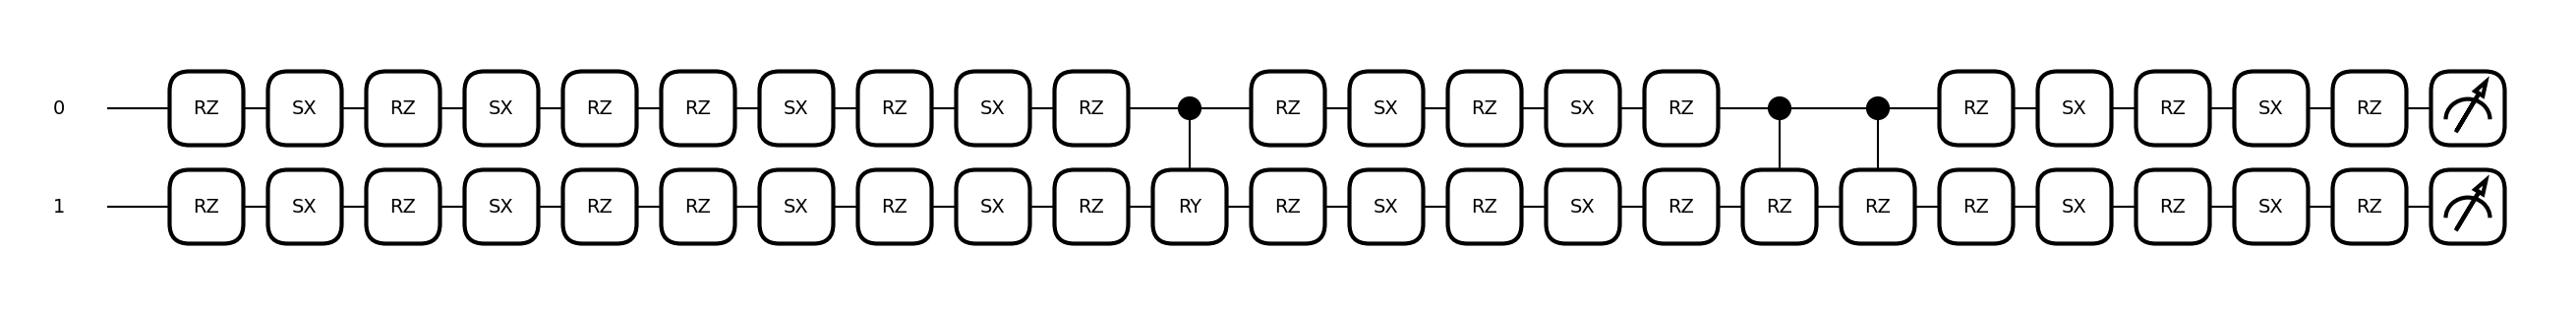

In [34]:
synthesiser.draw_circuit()

If you want the circuit object itself, you can call ```to_pennylane_circuit()```

In [35]:
synthesiser.to_pennylane_circuit()

<QNode: device='<default.qubit device (wires=2) at 0x316bb5af0>', interface='auto', diff_method='best'>

Furthermore we can get some neat information about our decomposition using the following functions

In [36]:
# Counts the number of leaves in the decomposition tree, i.e. # of single-qubit gates in the tree that must beconverted to actual
# gates in the final circuit.
synthesiser.count_leaves() 

8

In [37]:
# Returns the depth of the decomposition tree
synthesiser.get_depth()

2

In [38]:
# Counts the number of gates in the final circuit
synthesiser.count_gates()

{'SX': 16, 'Rz': 24, 'X': 0, 'CRY': 1, 'CRZ': 2}

In [39]:
# These can all be summarised 
synthesiser.get_info()

{'num_leaves': 8,
 'depth': 2,
 'gate_counts': {'SX': 16, 'Rz': 24, 'X': 0, 'CRY': 1, 'CRZ': 2}}